In [6]:
!pip install umap

ERROR: Could not find a version that satisfies the requirement umap (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for umap


In [3]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from src.utils import load_cifar10_longtail
import numpy as np
from tqdm import tqdm # Thư viện hiện thanh tiến trình

# 1. Thiết lập thiết bị
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng thiết bị: {device}")

# 2. Tải Model DINOv2
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
model.eval()

# 3. Transform chuẩn
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Lớp hỗ trợ để đưa dữ liệu vào DataLoader ---
class CifarLongtailDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img

# 4. Hàm trích xuất đặc trưng tối ưu (Xử lý theo Batch)
def extract_features_fast(X_images, batch_size=32):
    dataset = CifarLongtailDataset(X_images, transform=transform)
    # DataLoader giúp gộp các ảnh thành Batch để xử lý song song
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    feats = []
    # tqdm sẽ tạo ra thanh tiến trình 
    with torch.no_grad():
        for batch in tqdm(loader, desc="Đang trích xuất đặc trưng"):
            batch = batch.to(device)
            feat = model(batch)
            feats.append(feat.cpu().numpy())
            
    return np.vstack(feats)

# --- THỰC THI ---

X_longtail, Y_longtail = load_cifar10_longtail('../data/cifar-10-batches-py', imbalance_ratio=0.1)

# Trích xuất với Batch size 64 (Nếu máy có GPU mạnh bạn có thể tăng lên 128)
X_features = extract_features_fast(X_longtail, batch_size=64)

print(f"Xong! Kích thước mảng đặc trưng: {X_features.shape}")

# --- QUAN TRỌNG: Lưu lại để không phải chạy lại lần nữa ---
# Bạn hãy tạo folder 'processed_data' nếu chưa có
os.makedirs('../data/processed', exist_ok=True)
np.save('../data/processed/X_features_cifar_0.1.npy', X_features)
np.save('../data/processed/Y_longtail_cifar_0.1.npy', Y_longtail)
print("Đã lưu đặc trưng vào thư mục data/processed/")

KeyboardInterrupt: 

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import sys
import os
from sklearn.cluster import KMeans

# 1. Thêm đường dẫn src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.model_copy import hierarchical_kmeans_resampling

# 2. Load dữ liệu đặc trưng đã lưu (Đảm bảo đúng đường dẫn trong ảnh của bạn)
X_features = np.load('../data/processed/X_features_cifar_0.1.npy').astype(np.float32)
Y_longtail = np.load('../data/processed/Y_longtail_cifar_0.1.npy')

print(f"Đã load xong X_features: {X_features.shape}")
print(f"Đã load xong Y_longtail: {Y_longtail.shape}")

Đã load xong X_features: (20431, 384)
Đã load xong Y_longtail: (20431,)


# check embed

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Dùng dữ liệu gốc (đã norm) để check
clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X_features, Y_longtail, cv=3)
print(f"Chất lượng Embedding (Linear Accuracy): {scores.mean():.2%}")

Chất lượng Embedding (Linear Accuracy): 94.82%


In [3]:
for cls in range(10):
    idx = np.where(Y_longtail == cls)[0]
    points = X_features[idx]
    center = points.mean(axis=0)
    # Tính khoảng cách trung bình tới tâm lớp
    dist = np.mean(np.linalg.norm(points - center, axis=1))
    print(f"Lớp {cls}: Độ rộng không gian = {dist:.4f}")

Lớp 0: Độ rộng không gian = 38.3048
Lớp 1: Độ rộng không gian = 34.7160
Lớp 2: Độ rộng không gian = 41.9811
Lớp 3: Độ rộng không gian = 38.5695
Lớp 4: Độ rộng không gian = 36.9292
Lớp 5: Độ rộng không gian = 40.5818
Lớp 6: Độ rộng không gian = 38.6092
Lớp 7: Độ rộng không gian = 35.3093
Lớp 8: Độ rộng không gian = 36.0567
Lớp 9: Độ rộng không gian = 34.6688


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Bắt đầu Grid Testing với 6 cấu hình...

>>> Running: T=2, m=5, k_final=500... new hkm
--- Level 1/2 (k=1000, r_t tự động=10) ---
--- Level 2/2 (k=500, r_t tự động=1) ---
Xong! (7174 ảnh, 2.050 entropy)

>>> Running: T=2, m=10, k_final=500... new hkm
--- Level 1/2 (k=1000, r_t tự động=10) ---
--- Level 2/2 (k=500, r_t tự động=1) ---
Xong! (7262 ảnh, 2.071 entropy)

>>> Running: T=3, m=5, k_final=500... new hkm
--- Level 1/3 (k=1200, r_t tự động=8) ---
--- Level 2/3 (k=800, r_t tự động=1) ---
--- Level 3/3 (k=500, r_t tự động=1) ---
Xong! (6171 ảnh, 2.041 entropy)

>>> Running: T=3, m=10, k_final=500... new hkm
--- Level 1/3 (k=1200, r_t tự động=8) ---
--- Level 2/3 (k=800, r_t tự động=1) ---
--- Level 3/3 (k=500, r_t tự động=1) ---
Xong! (6100 ảnh, 2.009 entropy)

>>> Running: T=3, m=10, k_final=500... new hkm
--- Level 1/3 (k=1500, r_t tự động=6) ---
--- Level 2/3 (k=1000, r_t tự động=1) ---
--- Lev

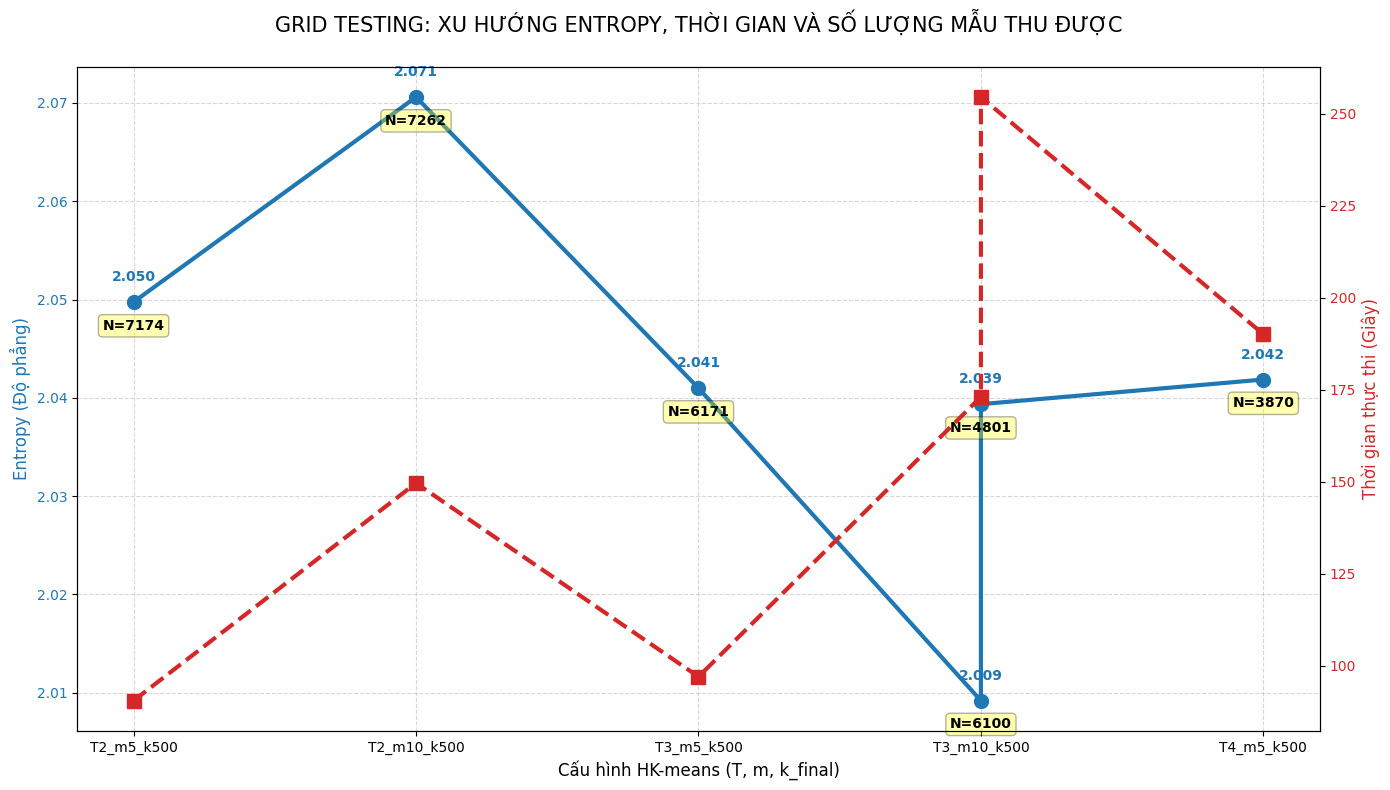

In [5]:
%load_ext autoreload
%autoreload 2
from sklearn.preprocessing import normalize
# --- CẤU HÌNH TỐI ƯU ---
X_feat_norm = normalize(X_features, axis=1)

import time
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
import numpy as np
from sklearn.cluster import KMeans

# --- 0. HÀM ĐO ENTROPY ---
def compute_entropy(labels):
    if len(labels) == 0: return 0
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    return entropy(probs)

# --- 1. ĐỊNH NGHĨA CÁC SETTING CẦN TEST ---
# Lưu ý: k_list phải có độ dài bằng T
test_configs = [
    {"T": 2, "m": 5,  "k_list": [1000, 500]},
    {"T": 2, "m": 10, "k_list": [1000, 500]},
    {"T": 3, "m": 5,  "k_list": [1200, 800, 500]},
    {"T": 3, "m": 10, "k_list": [1200, 800, 500]},
    {"T": 3, "m": 10, "k_list": [1500, 1000, 500]},
    {"T": 4, "m": 5,  "k_list": [2000, 1500, 1000, 500]},
]

results = []

print(f"Bắt đầu Grid Testing với {len(test_configs)} cấu hình...")

# --- 2. VÒNG LẶP GRID TESTING ---
for config in test_configs:
    T, m, k_list = config["T"], config["m"], config["k_list"]
    n_final_clusters = k_list[-1]
    
    print(f"\n>>> Running: T={T}, m={m}, k_final={n_final_clusters}...", end=" ")
    
    start_time = time.time()
    
    # a. Chạy HK-means (Hàm của bạn)
    centroids_final = hierarchical_kmeans_resampling(
        X_feat_norm, k_list=k_list, T=T, m=m, num_init=1, random_state=42
    )
    
    # b. Gán nhãn
    km_fine = KMeans(n_clusters=n_final_clusters, init=centroids_final, n_init=1).fit(X_feat_norm)
    labels_fine = km_fine.labels_
    
    # c. Lấy mẫu làm phẳng (Logic avg // 2 của bạn)
    avg_samples_per_cluster = len(X_feat_norm) // n_final_clusters
    target_per_cluster = max(1, avg_samples_per_cluster // 2) 
    
    curated_idx = []
    for i in range(n_final_clusters):
        idx_cluster = np.where(labels_fine == i)[0]
        if len(idx_cluster) == 0: continue
        dists = np.linalg.norm(X_feat_norm[idx_cluster] - centroids_final[i], axis=1)
        n_to_take = min(len(idx_cluster), target_per_cluster)
        curated_idx.extend(idx_cluster[np.argsort(dists)[:n_to_take]])
    
    end_time = time.time()
    
    # d. Ghi lại kết quả
    exec_time = end_time - start_time
    total_images = len(curated_idx)
    current_entropy = compute_entropy(Y_longtail[curated_idx])
    
    results.append({
        "Config": f"T{T}_m{m}_k{n_final_clusters}",
        "Time": exec_time,
        "Entropy": current_entropy,
        "Total_Images": total_images
    })
    print(f"Xong! ({total_images} ảnh, {current_entropy:.3f} entropy)")

# Chuyển kết quả sang DataFrame
df_res = pd.DataFrame(results)

# --- 3. VẼ BIỂU ĐỒ LINE CHART 2 TRỤC ---
fig, ax1 = plt.subplots(figsize=(14, 8))

# Trục 1: Entropy (Màu xanh - Blue)
color_ent = 'tab:blue'
ax1.set_xlabel('Cấu hình HK-means (T, m, k_final)', fontsize=12)
ax1.set_ylabel('Entropy (Độ phẳng)', color=color_ent, fontsize=12)
line1 = ax1.plot(df_res['Config'], df_res['Entropy'], color=color_ent, marker='o', markersize=10, linewidth=3, label='Entropy')
ax1.tick_params(axis='y', labelcolor=color_ent)
ax1.grid(True, linestyle='--', alpha=0.5)

# Trục 2: Thời gian (Màu đỏ - Red)
ax2 = ax1.twinx()
color_time = 'tab:red'
ax2.set_ylabel('Thời gian thực thi (Giây)', color=color_time, fontsize=12)
line2 = ax2.plot(df_res['Config'], df_res['Time'], color=color_time, marker='s', markersize=10, linestyle='--', linewidth=3, label='Thời gian')
ax2.tick_params(axis='y', labelcolor=color_time)

# --- 4. CHÚ THÍCH TỔNG SỐ HÌNH (Ghi đè lên điểm Entropy) ---
for i in range(len(df_res)):
    # Hiển thị số lượng ảnh thu được ngay dưới điểm dữ liệu Entropy
    ax1.annotate(f"N={df_res['Total_Images'][i]}", 
                 (df_res['Config'][i], df_res['Entropy'][i]),
                 textcoords="offset points", xytext=(0,-20), 
                 ha='center', fontsize=10, color='black', fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))
    
    # Hiển thị giá trị Entropy ngay trên điểm dữ liệu
    ax1.annotate(f"{df_res['Entropy'][i]:.3f}", 
                 (df_res['Config'][i], df_res['Entropy'][i]),
                 textcoords="offset points", xytext=(0,15), 
                 ha='center', fontsize=10, color=color_ent, fontweight='bold')

plt.title('GRID TESTING: XU HƯỚNG ENTROPY, THỜI GIAN VÀ SỐ LƯỢNG MẪU THU ĐƯỢC', fontsize=15, pad=25)
fig.tight_layout()
plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Bắt đầu Grid Testing với 6 cấu hình...

>>> Running: T=2, m=5, k_final=500... new hkm
--- Level 1/2 (k=1000, r_t tự động=10) ---
--- Level 2/2 (k=500, r_t tự động=1) ---


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=5.
  super()._check_params_vs_input(X, default_n_init=10)


Xong! (7174 ảnh, 2.050 entropy)

>>> Running: T=2, m=10, k_final=500... new hkm
--- Level 1/2 (k=1000, r_t tự động=10) ---
--- Level 2/2 (k=500, r_t tự động=1) ---


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=5.
  super()._check_params_vs_input(X, default_n_init=10)


Xong! (7281 ảnh, 2.071 entropy)

>>> Running: T=3, m=5, k_final=500... new hkm
--- Level 1/3 (k=1200, r_t tự động=8) ---
--- Level 2/3 (k=800, r_t tự động=1) ---
--- Level 3/3 (k=500, r_t tự động=1) ---


...

Xong! (6198 ảnh, 2.041 entropy)

>>> Running: T=3, m=10, k_final=500... new hkm
--- Level 1/3 (k=1500, r_t tự động=6) ---
--- Level 2/3 (k=1000, r_t tự động=1) ---
--- Level 3/3 (k=500, r_t tự động=1) ---


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=5.
  super()._check_params_vs_input(X, default_n_init=10)


Xong! (4864 ảnh, 2.049 entropy)

>>> Running: T=4, m=5, k_final=500... new hkm
--- Level 1/4 (k=2000, r_t tự động=5) ---
--- Level 2/4 (k=1500, r_t tự động=1) ---
--- Level 3/4 (k=1000, r_t tự động=1) ---
--- Level 4/4 (k=500, r_t tự động=1) ---


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=5.
  super()._check_params_vs_input(X, default_n_init=10)


Xong! (3885 ảnh, 2.049 entropy)


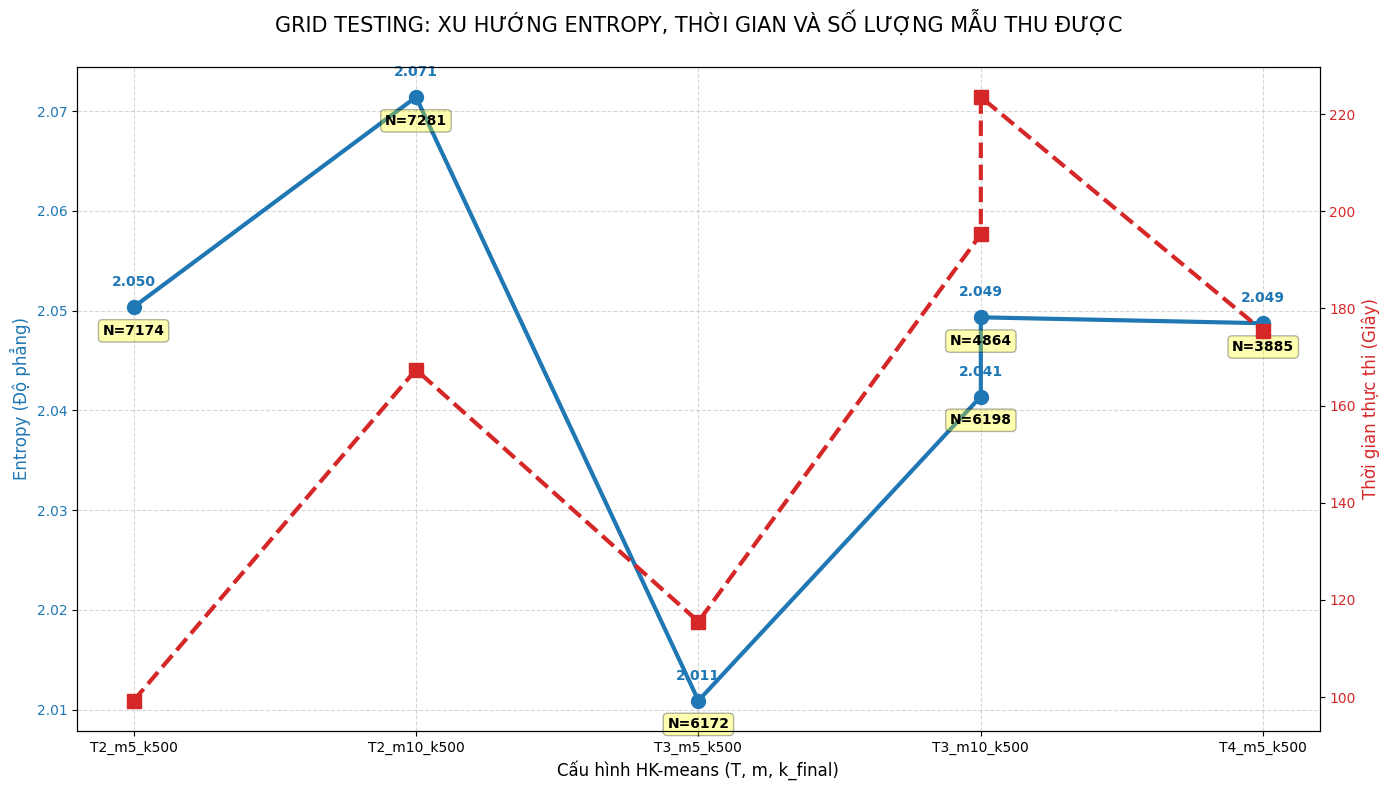

In [ ]:
%load_ext autoreload
%autoreload 2
from sklearn.preprocessing import normalize
# --- CẤU HÌNH TỐI ƯU ---
X_feat_norm = normalize(X_features, axis=1)

import time
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
import numpy as np
from sklearn.cluster import KMeans

# --- 0. HÀM ĐO ENTROPY ---
def compute_entropy(labels):
    if len(labels) == 0: return 0
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    return entropy(probs)

# --- 1. ĐỊNH NGHĨA CÁC SETTING CẦN TEST ---
# Lưu ý: k_list phải có độ dài bằng T
test_configs = [
    {"T": 2, "m": 5,  "k_list": [1000, 500]},
    {"T": 2, "m": 10, "k_list": [1000, 500]},
    {"T": 3, "m": 5,  "k_list": [1200, 800, 500]},
    {"T": 3, "m": 10, "k_list": [1200, 800, 500]},
    {"T": 3, "m": 10, "k_list": [1500, 1000, 500]},
    {"T": 4, "m": 5,  "k_list": [2000, 1500, 1000, 500]},
]

results = []

print(f"Bắt đầu Grid Testing với {len(test_configs)} cấu hình...")

# --- 2. VÒNG LẶP GRID TESTING ---
for config in test_configs:
    T, m, k_list = config["T"], config["m"], config["k_list"]
    n_final_clusters = k_list[-1]
    
    print(f"\n>>> Running: T={T}, m={m}, k_final={n_final_clusters}...", end=" ")
    
    start_time = time.time()
    
    # a. Chạy HK-means (Hàm của bạn)
    centroids_final = hierarchical_kmeans_resampling(
        X_feat_norm, k_list=k_list, T=T, m=m, num_init=1, random_state=42
    )
    
    # b. Gán nhãn
    km_fine = KMeans(n_clusters=n_final_clusters, init=centroids_final, n_init=5).fit(X_feat_norm)
    labels_fine = km_fine.labels_
    
    # c. Lấy mẫu làm phẳng (Logic avg // 2 của bạn)
    avg_samples_per_cluster = len(X_feat_norm) // n_final_clusters
    target_per_cluster = max(1, avg_samples_per_cluster // 2) 
    
    curated_idx = []
    for i in range(n_final_clusters):
        idx_cluster = np.where(labels_fine == i)[0]
        if len(idx_cluster) == 0: continue
        dists = np.linalg.norm(X_feat_norm[idx_cluster] - centroids_final[i], axis=1)
        n_to_take = min(len(idx_cluster), target_per_cluster)
        curated_idx.extend(idx_cluster[np.argsort(dists)[:n_to_take]])
    
    end_time = time.time()
    
    # d. Ghi lại kết quả
    exec_time = end_time - start_time
    total_images = len(curated_idx)
    current_entropy = compute_entropy(Y_longtail[curated_idx])
    
    results.append({
        "Config": f"T{T}_m{m}_k{n_final_clusters}",
        "Time": exec_time,
        "Entropy": current_entropy,
        "Total_Images": total_images
    })
    print(f"Xong! ({total_images} ảnh, {current_entropy:.3f} entropy)")

# Chuyển kết quả sang DataFrame
df_res = pd.DataFrame(results)

# --- 3. VẼ BIỂU ĐỒ LINE CHART 2 TRỤC ---
fig, ax1 = plt.subplots(figsize=(14, 8))

# Trục 1: Entropy (Màu xanh - Blue)
color_ent = 'tab:blue'
ax1.set_xlabel('Cấu hình HK-means (T, m, k_final)', fontsize=12)
ax1.set_ylabel('Entropy (Độ phẳng)', color=color_ent, fontsize=12)
line1 = ax1.plot(df_res['Config'], df_res['Entropy'], color=color_ent, marker='o', markersize=10, linewidth=3, label='Entropy')
ax1.tick_params(axis='y', labelcolor=color_ent)
ax1.grid(True, linestyle='--', alpha=0.5)

# Trục 2: Thời gian (Màu đỏ - Red)
ax2 = ax1.twinx()
color_time = 'tab:red'
ax2.set_ylabel('Thời gian thực thi (Giây)', color=color_time, fontsize=12)
line2 = ax2.plot(df_res['Config'], df_res['Time'], color=color_time, marker='s', markersize=10, linestyle='--', linewidth=3, label='Thời gian')
ax2.tick_params(axis='y', labelcolor=color_time)

# --- 4. CHÚ THÍCH TỔNG SỐ HÌNH (Ghi đè lên điểm Entropy) ---
for i in range(len(df_res)):
    # Hiển thị số lượng ảnh thu được ngay dưới điểm dữ liệu Entropy
    ax1.annotate(f"N={df_res['Total_Images'][i]}", 
                 (df_res['Config'][i], df_res['Entropy'][i]),
                 textcoords="offset points", xytext=(0,-20), 
                 ha='center', fontsize=10, color='black', fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))
    
    # Hiển thị giá trị Entropy ngay trên điểm dữ liệu
    ax1.annotate(f"{df_res['Entropy'][i]:.3f}", 
                 (df_res['Config'][i], df_res['Entropy'][i]),
                 textcoords="offset points", xytext=(0,15), 
                 ha='center', fontsize=10, color=color_ent, fontweight='bold')

plt.title('GRID TESTING: XU HƯỚNG ENTROPY, THỜI GIAN VÀ SỐ LƯỢNG MẪU THU ĐƯỢC', fontsize=15, pad=25)
fig.tight_layout()
plt.show()

In [11]:
# --- 1. Lấy mẫu ngẫu nhiên (Random Sampling - Baseline) ---
# Chọn đại 1000 ảnh từ toàn bộ dữ liệu gốc
random_indices = np.random.choice(len(X_features), 6000, replace=False)
Y_random_subset = Y_longtail[random_indices]

# --- 2. Lấy mẫu theo HK-means (Our Balanced Sampling) ---
# Ở bước này, hãy dùng đúng tên biến bạn đã tạo ở ô trên
curated_indices = []

# Thay vì range(100), bạn nên dùng range(n_final_clusters) hoặc range(500)
# vì ở bước trên bạn đã chia làm 500 cụm
for i in range(n_final_clusters): 
    # ĐỔI TÊN: cluster_labels -> labels_fine
    idx_in_cluster = np.where(labels_fine == i)[0]
    if len(idx_in_cluster) == 0: continue
    
    # ĐỔI TÊN: centroids_final -> centroids_cifar
    # ĐỔI TÊN: X_features -> X_feat_norm (vì bạn đã normalize ở bước trên)
    dists = np.linalg.norm(X_feat_norm[idx_in_cluster] - centroids_cifar[i], axis=1)
    
    # Lấy 2 ảnh gần nhất (để khớp với tổng ~1000 ảnh)
    top_k_idx = idx_in_cluster[np.argsort(dists)[:2]]
    curated_indices.extend(top_k_idx)

Y_curated_subset = Y_longtail[curated_indices]

### ưu tiên nhỏ

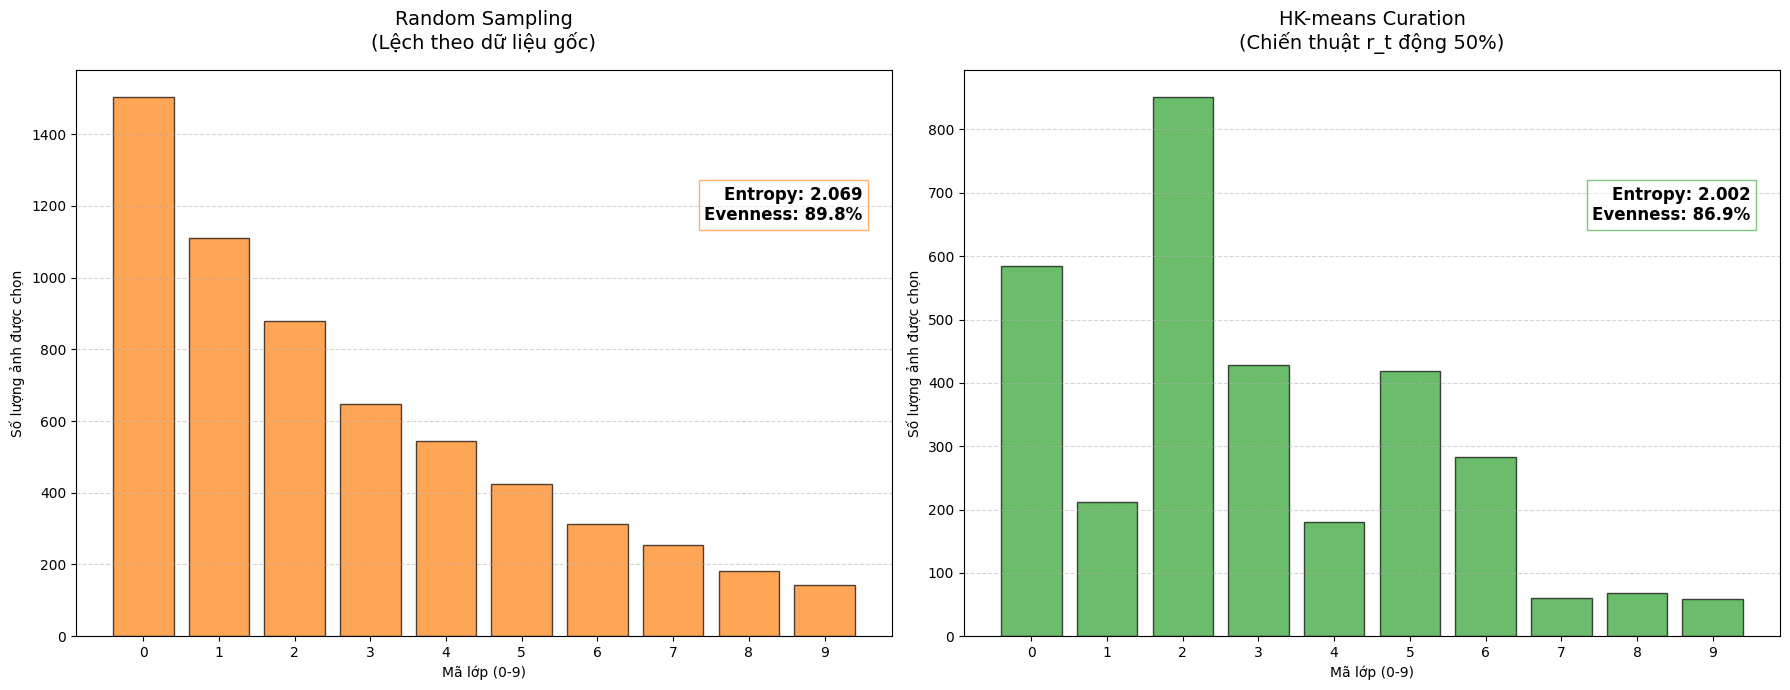

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_distribution(y_data, title, color):
    # 1. Thống kê số lượng
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    # 2. TÍNH ENTROPY VÀ ĐỘ PHẲNG
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    max_ent = np.log(10) # ln(10) xấp xỉ 2.302
    evenness = ent / max_ent
    
    # 3. VẼ BIỂU ĐỒ
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    # 4. CHÈN CHỈ SỐ LÊN HÌNH (Text box)
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    # Đặt text ở vị trí phía trên bên phải của mỗi biểu đồ
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title, fontsize=14, pad=15)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- THỰC HIỆN VẼ ---
plt.figure(figsize=(18, 7))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
# Giả sử Y_random_subset đã được tạo từ bước trước của bạn
plot_distribution(Y_random_subset, "Random Sampling\n(Lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Chiến thuật r_t động 50%)
plt.subplot(1, 2, 2)
# Dùng Y_curated_new bạn vừa tạo ra từ HK-means
plot_distribution(Y_curated_new, "HK-means Curation\n(Chiến thuật r_t động 50%)", "tab:green")

plt.tight_layout()
plt.show()

đổi quy tắt lấy đợt cuối (r/2)

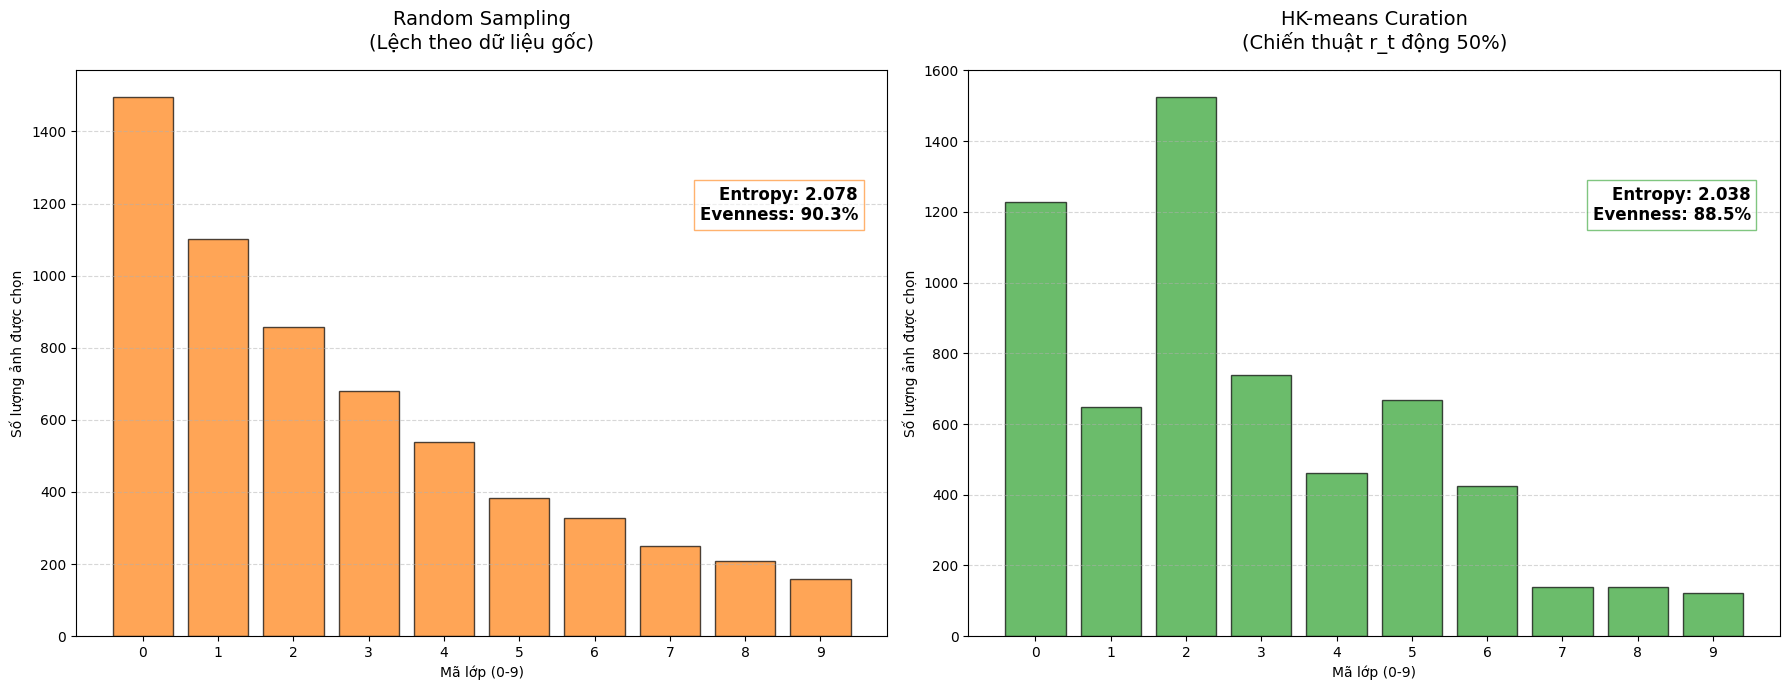

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_distribution(y_data, title, color):
    # 1. Thống kê số lượng
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    # 2. TÍNH ENTROPY VÀ ĐỘ PHẲNG
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    max_ent = np.log(10) # ln(10) xấp xỉ 2.302
    evenness = ent / max_ent
    
    # 3. VẼ BIỂU ĐỒ
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    # 4. CHÈN CHỈ SỐ LÊN HÌNH (Text box)
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    # Đặt text ở vị trí phía trên bên phải của mỗi biểu đồ
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title, fontsize=14, pad=15)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- THỰC HIỆN VẼ ---
plt.figure(figsize=(18, 7))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
# Giả sử Y_random_subset đã được tạo từ bước trước của bạn
plot_distribution(Y_random_subset, "Random Sampling\n(Lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Chiến thuật r_t động 50%)
plt.subplot(1, 2, 2)
# Dùng Y_curated_new bạn vừa tạo ra từ HK-means
plot_distribution(Y_curated_new, "HK-means Curation\n(Chiến thuật r_t động 50%)", "tab:green")

plt.tight_layout()
plt.show()


# --- CẤU HÌNH TỐI ƯU THỜI GIAN (10 PHÚT LEVEL 1) ---
T_steps = 3
# Level 1 để 1200 là đủ "mịn" cho 20k ảnh, 2000 là hơi dư thừa
k_list_fine = [1200, 800, 500] 

m_iterations = 10 # Giữ nguyên m=10 để centroids di chuyển tốt


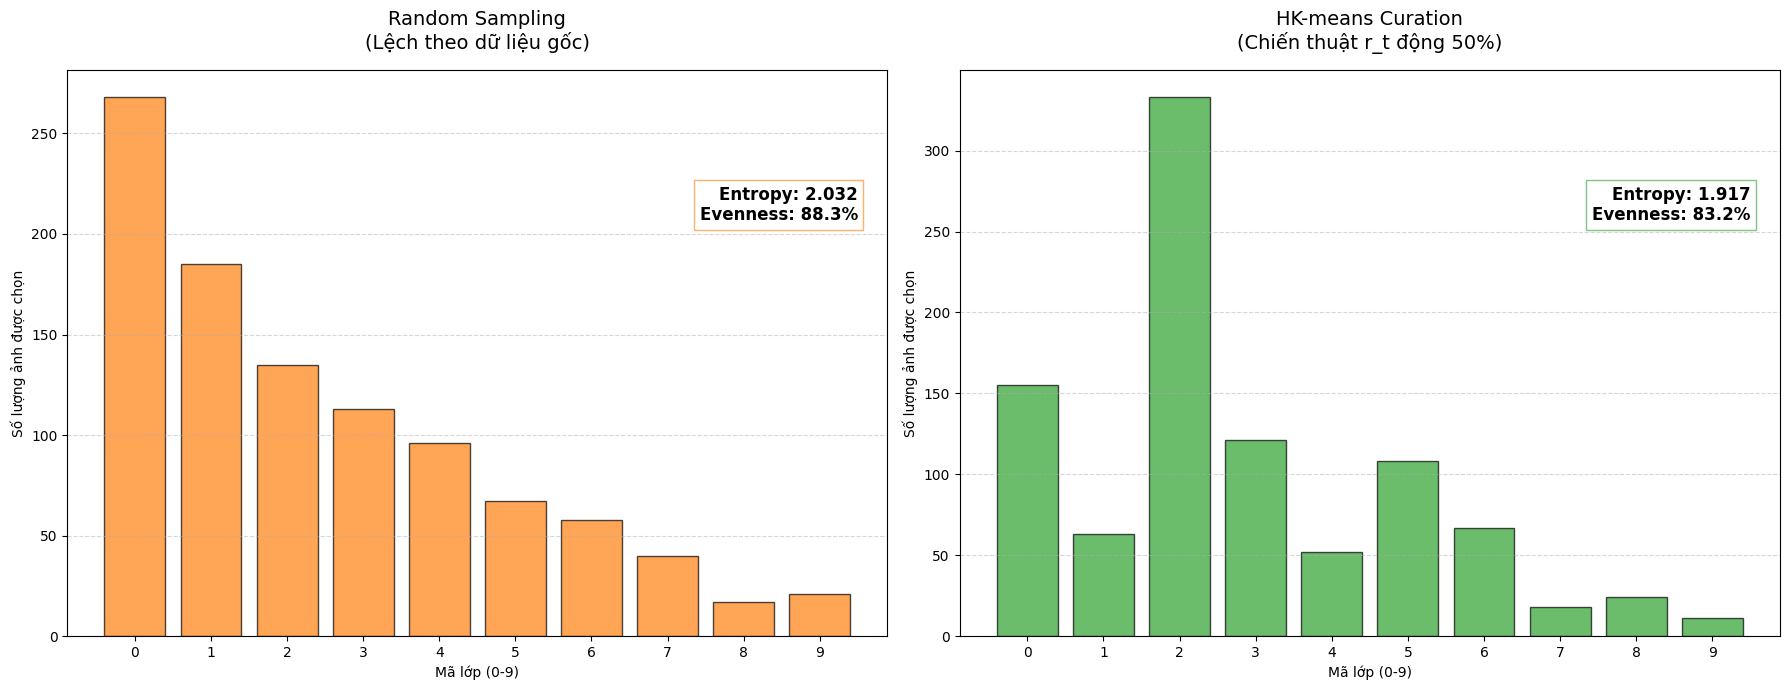

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_distribution(y_data, title, color):
    # 1. Thống kê số lượng
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    # 2. TÍNH ENTROPY VÀ ĐỘ PHẲNG
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    max_ent = np.log(10) # ln(10) xấp xỉ 2.302
    evenness = ent / max_ent
    
    # 3. VẼ BIỂU ĐỒ
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    # 4. CHÈN CHỈ SỐ LÊN HÌNH (Text box)
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    # Đặt text ở vị trí phía trên bên phải của mỗi biểu đồ
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title, fontsize=14, pad=15)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- THỰC HIỆN VẼ ---
plt.figure(figsize=(18, 7))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
# Giả sử Y_random_subset đã được tạo từ bước trước của bạn
plot_distribution(Y_random_subset, "Random Sampling\n(Lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Chiến thuật r_t động 50%)
plt.subplot(1, 2, 2)
# Dùng Y_curated_new bạn vừa tạo ra từ HK-means
plot_distribution(Y_curated_new, "HK-means Curation\n(Chiến thuật r_t động 50%)", "tab:green")

plt.tight_layout()
plt.show()

X_feat_norm = normalize(X_features, axis=1)

T_steps = 3
k_list_fine = [2000, 1000, 800]
m_iterations = 15 # Tăng m để tăng độ phẳng

# Gọi hàm với r_t tự động tính bên trong như bạn muốn
centroids_cifar = hierarchical_kmeans_resampling(
    X_feat_norm, 
    k_list_fine, 
    T=T_steps, 
    m=m_iterations, 
  
    num_init=5
)


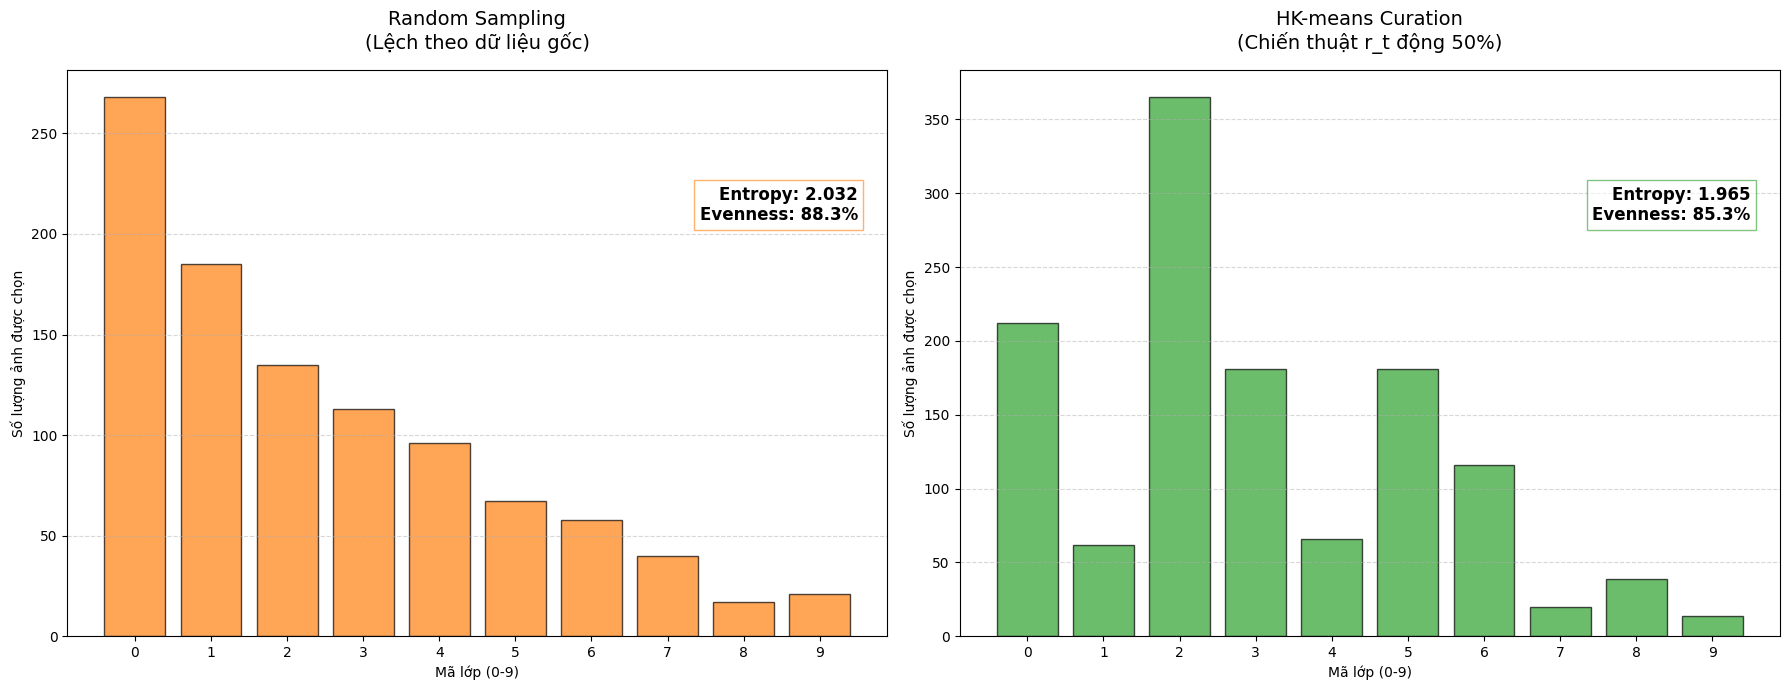

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_distribution(y_data, title, color):
    # 1. Thống kê số lượng
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    # 2. TÍNH ENTROPY VÀ ĐỘ PHẲNG
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    max_ent = np.log(10) # ln(10) xấp xỉ 2.302
    evenness = ent / max_ent
    
    # 3. VẼ BIỂU ĐỒ
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    # 4. CHÈN CHỈ SỐ LÊN HÌNH (Text box)
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    # Đặt text ở vị trí phía trên bên phải của mỗi biểu đồ
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title, fontsize=14, pad=15)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- THỰC HIỆN VẼ ---
plt.figure(figsize=(18, 7))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
# Giả sử Y_random_subset đã được tạo từ bước trước của bạn
plot_distribution(Y_random_subset, "Random Sampling\n(Lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Chiến thuật r_t động 50%)
plt.subplot(1, 2, 2)
# Dùng Y_curated_new bạn vừa tạo ra từ HK-means
plot_distribution(Y_curated_new, "HK-means Curation\n(Chiến thuật r_t động 50%)", "tab:green")

plt.tight_layout()
plt.show()

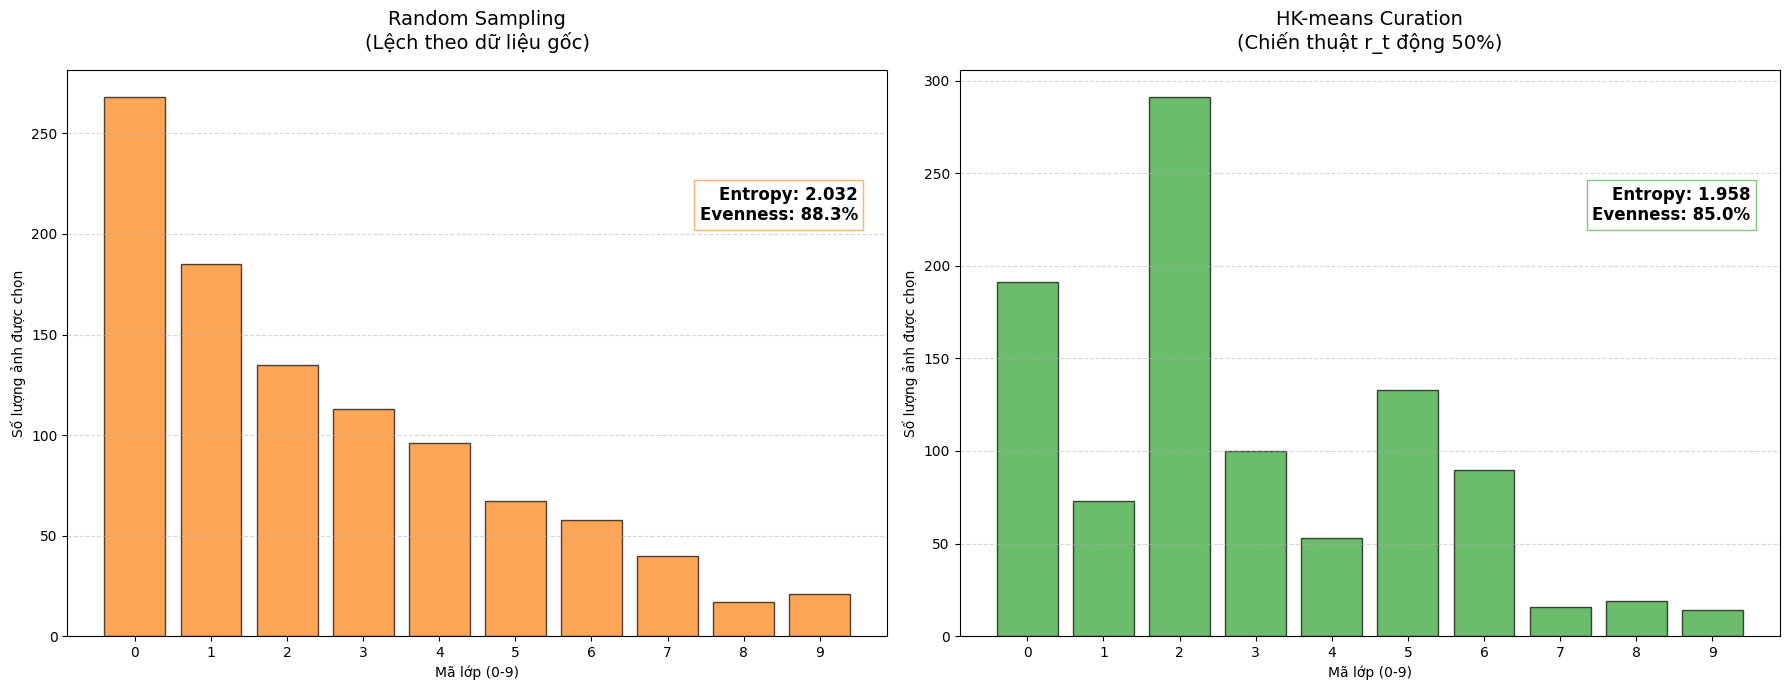

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_distribution(y_data, title, color):
    # 1. Thống kê số lượng
    classes, counts = np.unique(y_data, return_counts=True)
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[int(cls)] = count
        
    # 2. TÍNH ENTROPY VÀ ĐỘ PHẲNG
    probs = full_counts / np.sum(full_counts)
    ent = entropy(probs)
    max_ent = np.log(10) # ln(10) xấp xỉ 2.302
    evenness = ent / max_ent
    
    # 3. VẼ BIỂU ĐỒ
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    
    # 4. CHÈN CHỈ SỐ LÊN HÌNH (Text box)
    info_text = f"Entropy: {ent:.3f}\nEvenness: {evenness:.1%}"
    # Đặt text ở vị trí phía trên bên phải của mỗi biểu đồ
    plt.text(9.5, max(full_counts) * 0.8, info_text, 
             fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor=color),
             ha='right', va='center')

    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title, fontsize=14, pad=15)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- THỰC HIỆN VẼ ---
plt.figure(figsize=(18, 7))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
# Giả sử Y_random_subset đã được tạo từ bước trước của bạn
plot_distribution(Y_random_subset, "Random Sampling\n(Lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Chiến thuật r_t động 50%)
plt.subplot(1, 2, 2)
# Dùng Y_curated_new bạn vừa tạo ra từ HK-means
plot_distribution(Y_curated_new, "HK-means Curation\n(Chiến thuật r_t động 50%)", "tab:green")

plt.tight_layout()
plt.show()

# --- CẤU HÌNH TỐI ƯU ---
X_feat_norm = normalize(X_features, axis=1)

T_steps = 3
k_list_fine = [1000, 750, 500] 
m_iterations = 10 # Tăng m để tăng độ phẳng

# Gọi hàm với r_t tự động tính bên trong như bạn muốn
centroids_cifar = hierarchical_kmeans_resampling(
    X_feat_norm, 
    k_list_fine, 
    T=T_steps, 
    m=m_iterations, 
  
    num_init=5
)


In [8]:
%load_ext autoreload
%autoreload 2

import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import entropy
from tqdm import tqdm

# 1. SETUP VÀ LOAD DỮ LIỆU
sys.path.append(os.path.abspath(os.path.join('..')))
from src_author.hierarchical_kmeans_gpu import hierarchical_kmeans_with_resampling

if not hasattr(np, 'Inf'): np.Inf = np.inf
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_raw = np.load('../data/processed/X_features_cifar_0.1.npy').astype(np.float32)
Y_train = np.load('../data/processed/Y_longtail_cifar_0.1.npy')
X_test_raw = np.load('../data/processed/X_test_features.npy').astype(np.float32)
Y_test = np.load('../data/processed/Y_test_labels.npy')

X_train_norm = normalize(X_train_raw)
X_test_norm = normalize(X_test_raw)
X_train_tensor = torch.from_numpy(X_train_norm).to(device)

def run_eval_safe(indices):
    if len(indices) == 0: return 0.0, 0.0
    y_sub = Y_train[indices]
    if len(np.unique(y_sub)) < 2: return 0.0, 0.0
    try:
        clf = LogisticRegression(max_iter=1000).fit(X_train_norm[indices], y_sub)
        preds = clf.predict(X_test_norm)
        return accuracy_score(Y_test, preds), f1_score(Y_test, preds, average='macro')
    except: return 0.0, 0.0

# 2. ĐỊNH NGHĨA PHÂN PHỐI LÝ TƯỞNG (P)
P_uniform = np.full(10, 1/10) # Mỗi lớp chiếm đúng 10%

# 3. CẤU HÌNH GRID TEST
grid_configs = [
    ("1L_k300_rt2", [300], [2]),
    ("1L_k500_rt1", [500], [1]),
    ("2L_k800_300_rt5_2", [800, 300], [5, 2]),
    ("2L_k1000_300_rt2_1", [1000, 300], [2, 1]),
    ("2L_k1200_500_rt5_2", [1200, 500], [5, 2]),
    ("3L_k1000_600_300_rt5_2_1", [1000, 600, 300], [5, 2, 1]),
    ("3L_k1500_800_300_rt10_5_2", [1500, 800, 300], [10, 5, 2]),
    ("3L_k1500_800_500_rt5_2_2", [1500, 800, 500], [5, 2, 2]),
    ("3L_k2000_1000_500_rt5_2_1", [2000, 1000, 500], [5, 2, 1]),
    ("3L_k2000_1000_500_rt2_2_1", [2000, 1000, 500], [2, 2, 1])
]

grid_results = []
print(f"--- Bắt đầu Grid Testing (Thiết bị: {device}) ---")

for name, k_list, rt_list in grid_configs:
    print(f"Chạy: {name}", end=" | ")
    
    res = hierarchical_kmeans_with_resampling(
        data=X_train_tensor, n_clusters=k_list, n_levels=len(k_list),
        sample_sizes=rt_list, n_resamples=10, num_init=1, verbose=False
    )
    
    last_level = res[-1]
    assignment, centroids = last_level["assignment"], last_level["centroids"].cpu().numpy()
    
    curated_idx = []
    for c in range(k_list[-1]):
        c_idx = np.where(assignment == c)[0]
        if len(c_idx) == 0: continue
        dists = np.linalg.norm(X_train_norm[c_idx] - centroids[c], axis=1)
        curated_idx.extend(c_idx[np.argsort(dists)[:10]])
    
    # --- TÍNH TOÁN KL DIVERGENCE ---
    # Q: Phân phối lớp thực tế của tập lọc
    counts = np.bincount(Y_train[curated_idx], minlength=10)
    Q = (counts + 1e-10) / counts.sum() # Thêm epsilon tránh log(0)
    
    # KL Divergence của HK-means
    kl_ours = entropy(Q, P_uniform)
    
    # KL Divergence của Random Sampling (để đối chứng)
    rand_idx = np.random.choice(len(Y_train), len(curated_idx), replace=False)
    rand_counts = np.bincount(Y_train[rand_idx], minlength=10)
    Q_rand = (rand_counts + 1e-10) / rand_counts.sum()
    kl_rand = entropy(Q_rand, P_uniform)
    
    acc, f1 = run_eval_safe(curated_idx)
    
    grid_results.append({
        "Config": name,
        "Entropy": entropy(counts),
        "KL_Ours": kl_ours,
        "KL_Random": kl_rand,
        "Macro F1": f1,
        "Classes": len(np.unique(Y_train[curated_idx])),
        "Samples": len(curated_idx)
    })
    print(f"F1: {f1:.4f} | KL Ours: {kl_ours:.4f}")

# 4. HIỂN THỊ KẾT QUẢ
df_grid = pd.DataFrame(grid_results)
print("\n=== BẢNG SO SÁNH TỔNG HỢP ===")
display(df_grid.sort_values(by="Macro F1", ascending=False))

# 5. VẼ BIỂU ĐỒ XU HƯỚNG
plt.figure(figsize=(15, 6))

# Plot 1: Macro F1 vs KL Divergence
plt.subplot(1, 2, 1)
plt.plot(df_grid['Config'], df_grid['Macro F1'], marker='s', color='red', label='Macro F1-Score')
plt.plot(df_grid['Config'], df_grid['KL_Ours'], marker='o', color='green', label='KL Divergence (Ours)')
plt.title("Hiệu suất (F1) vs Độ lệch phân phối (KLD)")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: So sánh KLD Ours vs Random
plt.subplot(1, 2, 2)
x = np.arange(len(grid_configs))
plt.bar(x - 0.2, df_grid['KL_Ours'], 0.4, label='HK-means KLD', color='teal')
plt.bar(x + 0.2, df_grid['KL_Random'], 0.4, label='Random KLD', color='orange')
plt.xticks(x, df_grid['Config'], rotation=45, ha='right')
plt.title("So sánh KL Divergence (Thấp hơn là phẳng hơn)")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
--- Bắt đầu Grid Testing (Thiết bị: cpu) ---
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:09<00:00,  1.03it/s]
F1: 0.8926 | KL Ours: 0.2291
Chạy: 1L_k500_rt1 | F1: 0.9109 | KL Ours: 0.2391
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:12<00:00,  1.21s/it]
F1: 0.0000 | KL Ours: 2.3026
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:47<00:00,  4.71s/it]
F1: 0.0000 | KL Ours: 2.3026
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:19<00:00,  1.96s/it]
F1: 0.0000 | KL Ours: 2.3026
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:24<00:00,  2.42s/it]
F1: 0.0000 | KL Ours: 2.3026
Hierarchical k-means resampling steps:   0%|          | 0/10 [00:00<?, ?it/s]

: 